# Topic: Hierarchical Clustering

## Definition (30-second explanation)
* Hierarchical Clustering builds a tree of clusters (called a dendrogram) without requiring the number of clusters ($K$) to be specified in advance. 
* It works primarily by merging smaller clusters into larger ones (Agglomerative, or bottom-up), which is the most common approach.

## Why Interviewers Ask This
* To test your understanding of deterministic algorithms and how to evaluate datasets when the optimal $K$ is completely unknown.
* To evaluate your knowledge of distance calculations and linkage criteria trade-offs.

## Core Concepts
* **Dendrogram:** A tree diagram showing how clusters are merged at each level; cutting it at a specific height gives you the desired number of clusters.
* **Agglomerative vs. Divisive:** Agglomerative is bottom-up (starts with individual points and merges), whereas Divisive is top-down (starts with one large cluster and splits).
* **Ward Linkage:** The most common general-purpose linkage method; it merges clusters by minimizing the total within-cluster variance.
* **Other Linkages:** Single linkage uses the minimum distance between points (prone to chaining), Complete uses the maximum distance (compact clusters), and Average uses the average distance.

## When to Use
* When you do not know the number of clusters in advance and need to understand the natural hierarchy of groupings.
* When cluster sizes vary significantly, which is a scenario where K-Means typically struggles.
* When working with small to medium datasets.

## Advantages
* Highly visual and flexible; the dendrogram allows you to visually inspect groupings and cut at any level to obtain clusters.
* Deterministic algorithm, meaning it yields the exact same result every time, unlike K-Means which relies on random initialization.

## Limitations
* Computationally expensive and slow; the time complexity is $O(n^2)$ or $O(n^3)$, making it unsuitable for very large datasets.
* Can be sensitive to noise, particularly when using Single linkage, which creates incorrect, long chain-like clusters.

## Common Comparisons
* **Hierarchical vs K-Means:** Hierarchical requires no $K$ upfront, is deterministic, and handles varying cluster shapes, but is very slow ($O(n^2)$). K-Means is extremely fast and scalable but requires $K$, assumes spherical shapes, and has random initialization.

## Common Interview Traps
* **Forgetting to scale:** Ward linkage relies on variance, which is highly scale-sensitive. Failing to scale features is a critical mistake.
* **Applying to big data:** Recommending hierarchical clustering for a dataset with millions of rows shows a lack of algorithmic complexity awareness ($O(n^2)$ memory and time).
* **Incorrect dendrogram cutting:** Not knowing that you must look for the longest vertical line before a horizontal merge to find the optimal cut.

## Python Syntax
* `from sklearn.cluster import AgglomerativeClustering`
* `from scipy.cluster.hierarchy import dendrogram, linkage`
* `Z = linkage(X_scaled, method="ward")`
* `agg = AgglomerativeClustering(n_clusters=4, linkage="ward")`

## 45-Second Interview Answer
"Hierarchical clustering is an unsupervised technique that builds a tree-like dendrogram to group data without needing $K$ upfront. I typically use the Agglomerative bottom-up approach with Ward linkage, which minimizes within-cluster variance. Because Ward relies on variance, I always scale features first. It's excellent for small datasets where visual interpretability of the cluster hierarchy is required, but for larger datasets, I switch to K-Means due to Hierarchical's heavy $O(n^2)$ time and memory complexity."

## Topic: Reading a Dendrogram for Optimal K

## How to Determine K Visually
* **Step 1:** Scan the dendrogram to find the **longest continuous vertical line** that is not intersected by any horizontal merging lines. This represents the largest jump in distance/variance between merges.
* **Step 2:** Draw an imaginary horizontal line straight across that longest vertical section.
* **Step 3:** Count exactly how many vertical lines your imaginary horizontal line crosses. That number is your optimal $K$.

## Why This Works
* A long vertical line means the algorithm had to increase the distance threshold significantly to force those two clusters together. 
* This massive jump implies the clusters were naturally very far apart, signaling that you have reached the natural boundaries of the data segments.

## Practice Questions:

### Q1:
"You are given customer transaction data with no labels. Your goal is to discover customer segments. You do not know how many segments exist. Which clustering algorithm would you use and why?"

**Answer:**
I would start with Hierarchical Clustering (specifically Agglomerative with Ward linkage). Because I do not know K in advance, the resulting dendrogram will visually show me the natural groupings and help identify the right number of clusters. It also handles varying cluster sizes well. Once I identify the optimal number of clusters from the dendrogram, if the dataset is large, I would switch to K-Means for scalability. Finally, I would evaluate the segments using the Silhouette Score.

**Common mistakes candidates make:**
* Suggesting K-Means immediately without explaining how they would guess or find $K$ first.
* Failing to mention the scalability limits of Hierarchical Clustering (not acknowledging that they might need to switch to K-Means if the transaction data is massive).

**One likely interviewer follow-up:**
"You mentioned looking at the dendrogram to find the optimal number of clusters. Exactly how do you read a dendrogram to determine where to make that cut?"

### Q2: Linkage Criteria & Outliers

**Question:**
If you use Single Linkage on a dataset with scattered outliers, what will likely happen to your cluster shapes? Why is Ward Linkage a safer choice for business segmentation?

**Answer:**
Single linkage merges clusters based on the minimum distance between their closest edge points. If outliers bridge the gap between distinct groups, Single linkage will "hop" along these noisy points, resulting in the "chaining effect" where it creates a massive, snake-like cluster. On a dendrogram, this looks like a staggered staircase. 

Ward Linkage is much safer because it merges clusters only if the total within-cluster variance is minimized. Adding an extreme outlier to a dense cluster would cause a massive variance penalty, so Ward refuses to swallow the outlier, keeping the main clusters compact and balanced.

---

### Visual Cheat Sheet: Hierarchical Linkages

Assume we have two clusters: `Cluster A` [ * * * ] and `Cluster B` [ * * * ]

**1. Single Linkage (Minimum Distance)**
*   **Rule:** Shortest gap between any two points.
*   **Visual:**  [ * * * ] <------> [ * * * ]  *(Measures closest edges)*
*   **Risk:** "Chaining" (snake-like shapes). Highly sensitive to noise.

**2. Complete Linkage (Maximum Distance)**
*   **Rule:** Longest gap between any two points.
*   **Visual:**  [ * * * ] <------------------> [ * * * ] *(Measures furthest edges)*
*   **Risk:** Tends to break large clusters; sensitive to outliers on the far edges.

**3. Average Linkage (Average Distance)**
*   **Rule:** Average of all pairwise distances between points in A and B.
*   **Visual:**  [ * * * ] <====> [ * * * ] *(Measures all possible connections)*
*   **Risk:** A compromise between Single and Complete. 

**4. Ward Linkage (Variance Minimization)**
*   **Rule:** Merges clusters that result in the smallest increase in total variance.
*   **Visual:**  [   ( X )   ] *(Finds the geometric center of mass and keeps it tight)*
*   **Risk:** The safest, default choice, but forces spherical clusters (similar to K-Means).

### Q3:
**Question:**
Write a script to scale a dataset, plot side-by-side dendrograms comparing Single vs. Ward linkage, and evaluate an Agglomerative model using the Silhouette Score.

In [24]:
# Data:
import pandas as pd
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# Generate mock data: 2 intertwined moon shapes with some noise
X, _ = make_moons(n_samples=250, noise=0.08, random_state=42)
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [25]:
df

,Feature_1,Feature_2
0,0.079850,0.131851
1,1.088384,0.156680
2,-0.681479,0.701807
3,0.067101,0.883238
4,-1.036356,0.358662
...,...,...
245,-0.947998,0.400763
246,0.971259,0.316162
247,-0.787762,0.636844
248,0.841723,-0.588227


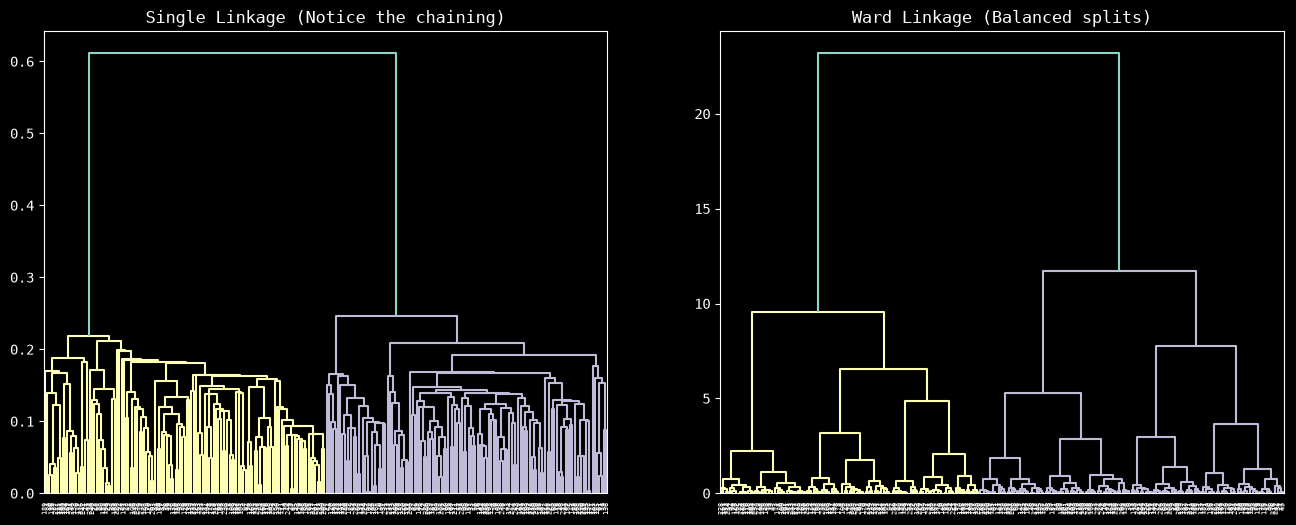

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

# 1. Preprocess
X_scaled = StandardScaler().fit_transform(df)

# 2. Visualize Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Single Linkage Dendrogram
dend1 = linkage(X_scaled, method='single')
dendrogram(dend1, ax=axes[0])
axes[0].set_title('Single Linkage (Notice the chaining)', color='white')
axes[0].grid(False)

# Ward Linkage Dendrogram
dend2 = linkage(X_scaled, method='ward')
dendrogram(dend2, ax=axes[1])
axes[1].set_title('Ward Linkage (Balanced splits)', color='white')
axes[1].grid(False)

plt.show()

In [27]:
# 3. Model & Evaluate
model = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
labels = model.fit_predict(X_scaled)
print(f"Silhouette Score: {silhouette_score(X_scaled, labels):.3f}")

Silhouette Score: 0.449


**Interview Tips:**

- metric='euclidean' is the default in scikit-learn for Ward linkage (Ward actually requires Euclidean distance mathematically).

- Using plt.subplots shows you know how to build comparative dashboards, a great skill when preparing visual content for stakeholders or external distribution.